# Data Overview: rawdata.json

This notebook analyzes store data from `data/rawdata.json`:
- Map all stores on a Croatia basemap.
- Plot distributions for number of ratings and rating.
- Show a regression plot of ratings vs. number of ratings.
- Plot a review-weighted heatmap (red = more reviews) on the Croatia map.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_PATH = Path("..") / "data" / "rawdata.json"

with DATA_PATH.open("r", encoding="utf-8") as f:
    raw = json.load(f)

# Flatten dict-of-objects into a table
keys = list(raw.keys())
df = pd.json_normalize(list(raw.values()))
df["source_id"] = keys

# Extract lon/lat from the coordinates array
coords = df.get("coordinates")
if coords is not None:
    coords = coords.apply(
        lambda c: c if isinstance(c, list) and len(c) >= 2 else [np.nan, np.nan]
    )
    df["lon"] = coords.apply(lambda c: c[0])
    df["lat"] = coords.apply(lambda c: c[1])
else:
    df["lon"] = np.nan
    df["lat"] = np.nan

# Coerce numeric fields
for col in ["rating", "user_ratings_total"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Cleaned dataset for plotting
required_cols = ["lat", "lon", "rating", "user_ratings_total"]
df_clean = df.dropna(subset=[c for c in required_cols if c in df.columns]).copy()

# Detect coordinate outliers using robust z-scores (MAD)
lon_median = df_clean["lon"].median()
lat_median = df_clean["lat"].median()

lon_mad = np.median(np.abs(df_clean["lon"] - lon_median))
lat_mad = np.median(np.abs(df_clean["lat"] - lat_median))

# Avoid division by zero if MAD is 0
lon_mad = lon_mad if lon_mad > 0 else 1e-9
lat_mad = lat_mad if lat_mad > 0 else 1e-9

lon_robust_z = 0.6745 * (df_clean["lon"] - lon_median) / lon_mad
lat_robust_z = 0.6745 * (df_clean["lat"] - lat_median) / lat_mad

coord_outlier_mask = (np.abs(lon_robust_z) > 6) | (np.abs(lat_robust_z) > 6)

outliers = df_clean.loc[coord_outlier_mask, ["name", "brand", "lat", "lon", "formatted_address"]]

print(f"Rows in raw data: {len(df)}")
print(f"Rows after cleaning (before outlier removal): {len(df_clean)}")
print(f"Coordinate outliers detected: {len(outliers)}")
if len(outliers) > 0:
    display(outliers)

# Exclude coordinate outliers
if len(outliers) > 0:
    df_clean = df_clean.loc[~coord_outlier_mask].copy()

print(f"Rows after outlier removal: {len(df_clean)}")
df_clean.head()

Rows in raw data: 4177
Rows after cleaning (before outlier removal): 4177
Coordinate outliers detected: 1


,name,brand,lat,lon,formatted_address
760,INTERSPAR,,16.966566,46.153412,"Prilaz V.Holjevca 12, 47000, Karlovac, Croatia"


Rows after outlier removal: 4176


,name,brand,rating,user_ratings_total,formatted_address,coordinates,source_id,lon,lat
0,Spar,Spar,4.1,1002,"Ul. Ivana Banjavčića 22A, 10000, Zagreb, Croatia","[16.0011734, 45.8095893]",relation/6308508,16.001173,45.809589
1,SPAR supermarket Zagreb Zagrebačka,Spar,4.0,1213,"Zagrebačka cesta 3, 10000, Zagreb, Croatia","[15.9322674, 45.8137023]",way/29274000,15.932267,45.813702
2,Vrutak,,4.6,2526,"Vodovodna ul. 20A, 10000, Zagreb, Croatia","[15.9459326, 45.8089715]",way/29274027,15.945933,45.808971
3,Konzum,Konzum,4.0,1104,"Ul. grada Vukovara 275, 10000, Zagreb, Croatia","[16.013879, 45.8038215]",way/29623117,16.013879,45.803821
4,Konzum,Konzum,3.3,25,"Froudeova ul. 5, 10000, Zagreb, Croatia","[15.9724847, 45.7766091]",way/29640096,15.972485,45.776609


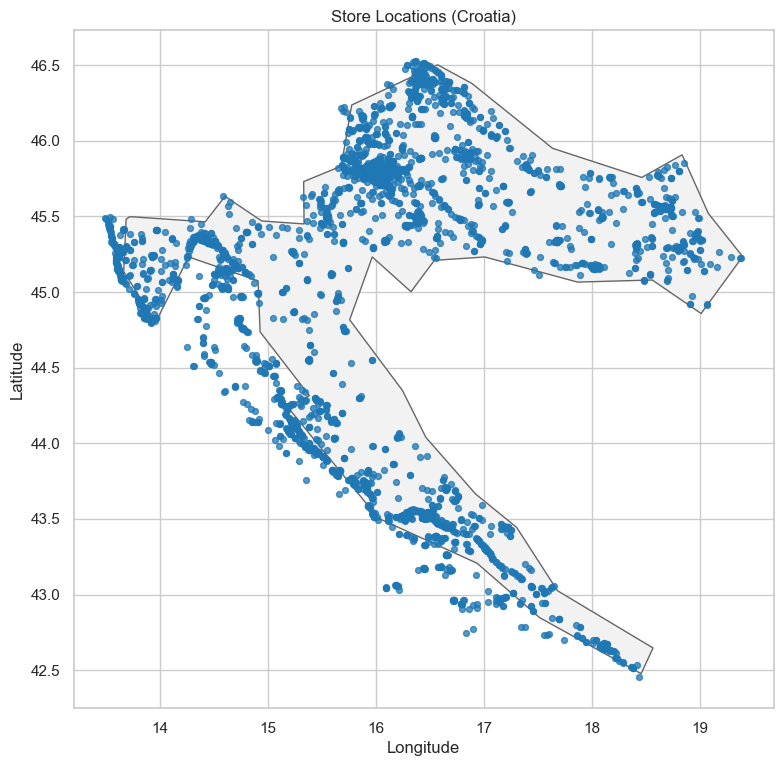

In [2]:
import geopandas as gpd
from shapely.geometry import Point

# Natural Earth dataset URL (GeoPandas datasets module removed in 1.0)
NE_COUNTRIES_URL = (
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)
world = gpd.read_file(NE_COUNTRIES_URL)

name_col = next(
    (col for col in ["name", "NAME", "ADMIN", "SOVEREIGNT"] if col in world.columns),
    None,
)
if name_col is None:
    raise KeyError("No country name column found in Natural Earth dataset")

croatia = world[world[name_col].astype(str).str.lower() == "croatia"]

geometry = [Point(xy) for xy in zip(df_clean["lon"], df_clean["lat"])]
gdf = gpd.GeoDataFrame(df_clean, geometry=geometry, crs="EPSG:4326")

fig, ax = plt.subplots(figsize=(8, 8))
croatia.plot(ax=ax, color="#f2f2f2", edgecolor="#666666")
gdf.plot(ax=ax, color="#1f77b4", markersize=18, alpha=0.75)

ax.set_title("Store Locations (Croatia)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

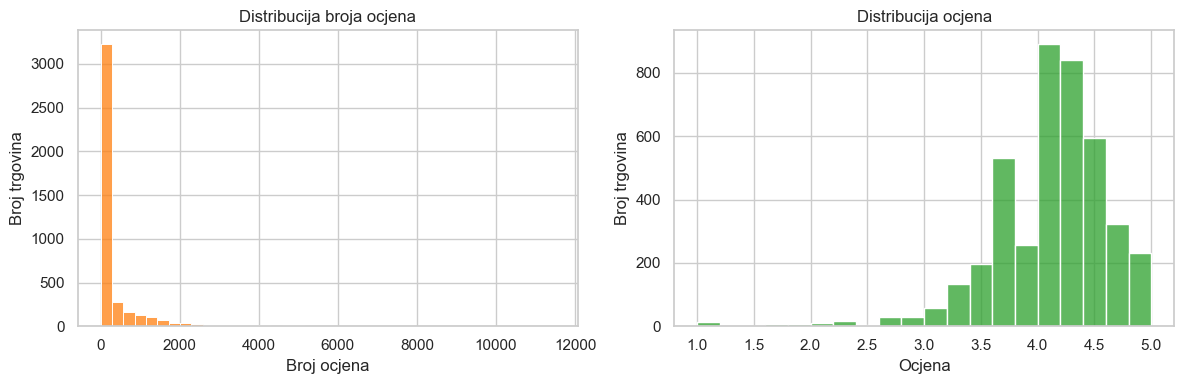

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_clean["user_ratings_total"], bins=40, ax=axes[0], color="#ff7f0e")
axes[0].set_title("Distribucija broja ocjena")
axes[0].set_xlabel("Broj ocjena")
axes[0].set_ylabel("Broj trgovina")

sns.histplot(df_clean["rating"], bins=20, ax=axes[1], color="#2ca02c")
axes[1].set_title("Distribucija ocjena")
axes[1].set_xlabel("Ocjena")
axes[1].set_ylabel("Broj trgovina")

plt.tight_layout()
plt.show()

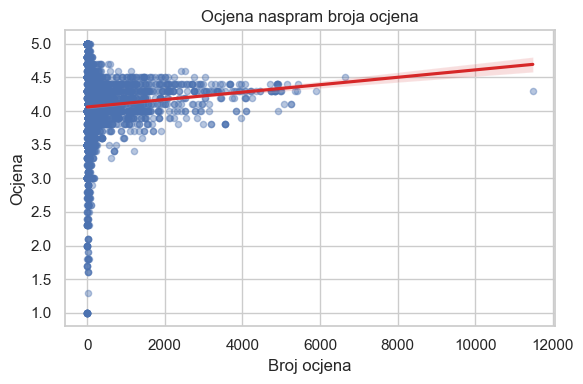

In [4]:
plt.figure(figsize=(6, 4))

sns.regplot(
    data=df_clean,
    x="user_ratings_total",
    y="rating",
    scatter_kws={"alpha": 0.4, "s": 20},
    line_kws={"color": "#d62728"},
)

plt.title("Ocjena naspram broja ocjena")
plt.xlabel("Broj ocjena")
plt.ylabel("Ocjena")
plt.tight_layout()
plt.show()

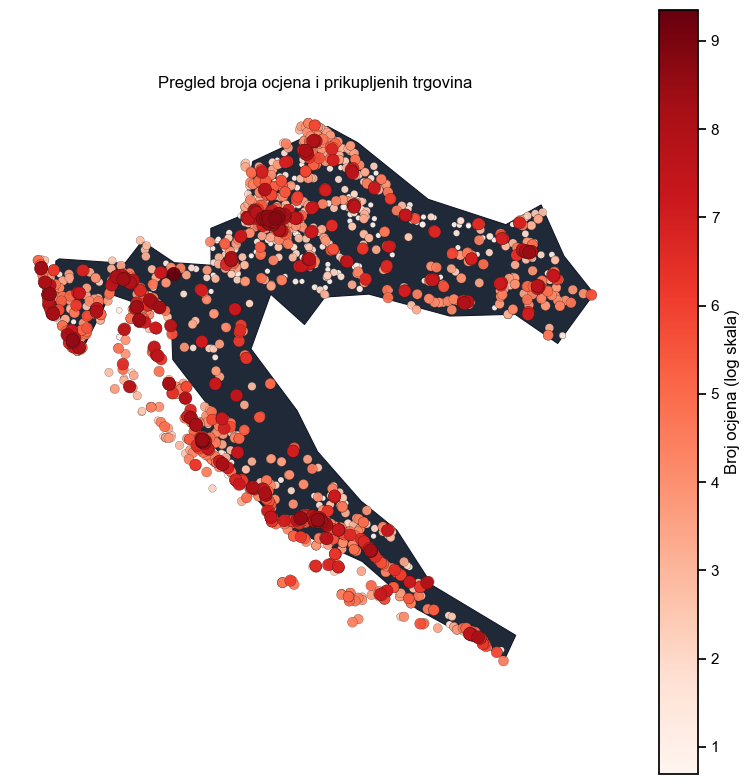

In [16]:
from matplotlib.colors import Normalize

# Sort so higher-review stores plot last (on top)
gdf_sorted = gdf.sort_values("user_ratings_total")

review_counts = gdf_sorted["user_ratings_total"].values
review_counts_log = np.log1p(review_counts)

norm = Normalize(vmin=review_counts_log.min(), vmax=review_counts_log.max())
colors = plt.cm.Reds(norm(review_counts_log))

# Scale point size gently by log review count to enhance visibility
sizes = 15 + 85 * norm(review_counts_log)

fig, ax = plt.subplots(figsize=(8, 8), facecolor="#ffffff")
ax.set_facecolor("#ffffff")

croatia.plot(ax=ax, color="#1f2937", edgecolor="#111827", linewidth=0.8)
gdf_sorted.plot(ax=ax, color=colors, markersize=sizes, alpha=0.95, edgecolor="#111111", linewidth=0.15)

sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
sm.set_array([])

cbar = plt.colorbar(sm, ax=ax, label="Broj ocjena (log skala)")
cbar.ax.yaxis.label.set_color("#000000")
cbar.ax.tick_params(colors="#000000")
cbar.outline.set_edgecolor("#000000")

ax.set_title("Pregled broja ocjena i prikupljenih trgovina", color="#000000")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

## External Data Correlations

This section loads `data/external_data/external_data_raw.json` and compares `user_ratings_total` against the external numeric features.


In [6]:
EXTERNAL_DATA_PATH = Path("..") / "data" / "external_data" / "external_data_raw.json"

with EXTERNAL_DATA_PATH.open("r", encoding="utf-8") as f:
    external_raw = json.load(f)

external_keys = list(external_raw.keys())
external_df = pd.json_normalize(list(external_raw.values()))
external_df["source_id"] = external_keys

external_numeric_cols = [
    "user_ratings_total",
    "sales_area",
    "total_sales_2023",
    "total_sales_2024",
    "sale_entries_2023",
    "sale_entries_2024",
]

for col in external_numeric_cols:
    if col in external_df.columns:
        external_df[col] = pd.to_numeric(external_df[col], errors="coerce")

external_corr_df = external_df.dropna(subset=["user_ratings_total"]).copy()
preview_cols = [
    col
    for col in ["source_id", "name", *external_numeric_cols]
    if col in external_corr_df.columns
]

print(f"Rows in external data: {len(external_df)}")
print(f"Rows with user_ratings_total: {len(external_corr_df)}")
display(external_corr_df[preview_cols].head())


Rows in external data: 1306
Rows with user_ratings_total: 1306


,source_id,name,user_ratings_total,sales_area,total_sales_2023,total_sales_2024,sale_entries_2023,sale_entries_2024
0,external/3,Velebitska,40,98.0,114182.373070,69582.252109,345,219
1,external/5,Omiš,629,213.0,285874.913258,223471.951297,346,222
2,external/7,Dugi Rat,209,279.0,236787.674678,155696.086265,346,222
3,external/8,Lastovo,87,66.4,17713.827789,21204.571065,100,86
4,external/11,Šižgorićeva,106,100.0,82006.270890,49168.113958,346,217


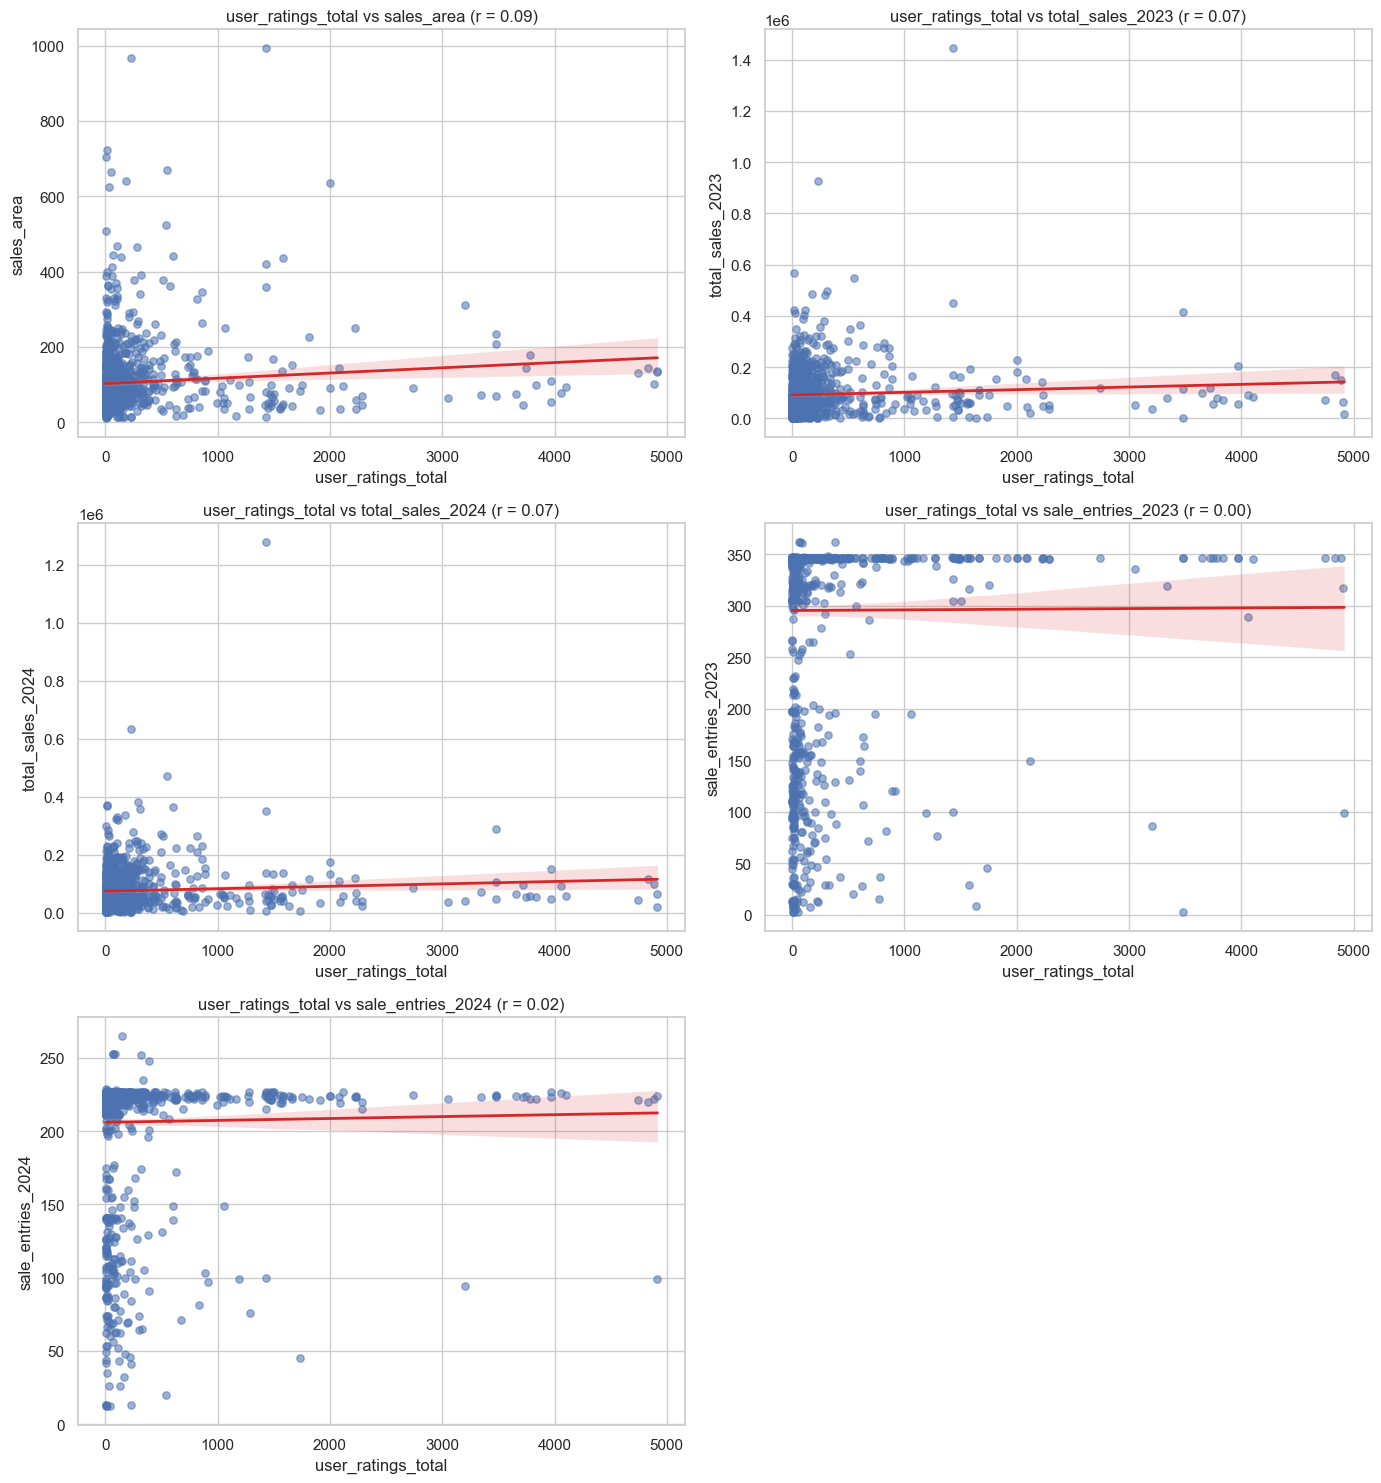

In [7]:
external_feature_cols = [
    "sales_area",
    "total_sales_2023",
    "total_sales_2024",
    "sale_entries_2023",
    "sale_entries_2024",
]

available_features = [
    col
    for col in external_feature_cols
    if col in external_corr_df.columns and external_corr_df[col].notna().any()
]

if not available_features:
    print("No external numeric features available for plotting.")
else:
    ncols = 2
    nrows = int(np.ceil(len(available_features) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 5 * nrows))
    axes = np.array(axes).reshape(-1)

    for ax, feature in zip(axes, available_features):
        plot_df = external_corr_df.dropna(subset=["user_ratings_total", feature])
        correlation = plot_df["user_ratings_total"].corr(plot_df[feature])

        sns.regplot(
            data=plot_df,
            x="user_ratings_total",
            y=feature,
            ax=ax,
            scatter_kws={"alpha": 0.55, "s": 28},
            line_kws={"color": "#d62728", "linewidth": 2},
        )

        ax.set_title(f"user_ratings_total vs {feature} (r = {correlation:.2f})")
        ax.set_xlabel("user_ratings_total")
        ax.set_ylabel(feature)

    for ax in axes[len(available_features):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()
